In [1]:
import os
import re
import pandas as pd
import nilearn as nl
import numpy as np
import seaborn as sns
from nilearn.input_data import NiftiMasker
from nilearn.image.image import mean_img
from nilearn import plotting, image
from nilearn.plotting import view_img
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from nilearn.image import math_img
import time
import multiprocessing






/opt/anaconda3/lib/python3.8/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


In [2]:
#f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
#    '../derivatives/') for f in files if 
#          (('me1' in f) & (f.endswith('desc-preproc_bold.nii.gz')))|
#         (('me4' in f ) & (f.endswith('desc-optcom-dewarped_bold.nii.gz')))]

f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
   '../derivatives/fmriprep_1') for f in files if f.endswith('space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz')]
sub_list=["sub-10017","sub-10024",'sub-10035','sub-10043','sub-10054','sub-10059','sub-10074','sub-10080',
          'sub-10108','sub-10125','sub-10136','sub-10137','sub-10142','sub-10150','sub-10154','sub-10186',
         'sub-10188','sub-10221']
f_list=[f for f in f_list if any(substring in f for substring in sub_list)]
display(f_list)

[]

# Making anatomical Masks and getting files

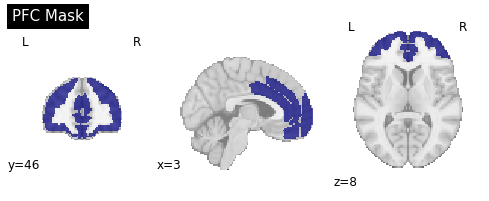

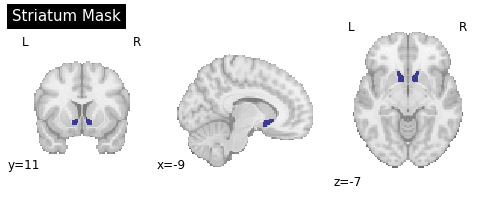

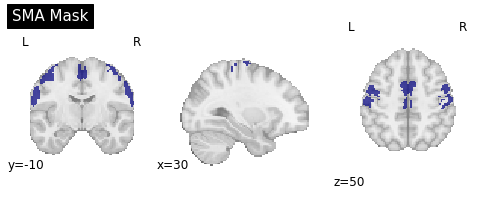

In [3]:
from nilearn import image,datasets,masking,plotting,input_data
#Striatum Mask



HO_sub=datasets.fetch_atlas_harvard_oxford(atlas_name='sub-maxprob-thr25-2mm')

keep = [idx for idx, s in enumerate(HO_sub.labels) if
        'Accumbens' in s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_sub.maps) for idx in keep]   

str_regions=image.concat_imgs(np.array(keepimg_list))
str_mask=masking.compute_background_mask(str_regions)
str_mask=NiftiMasker(mask_img=str_mask)

#MPFC mask
HO_cort=datasets.fetch_atlas_harvard_oxford(atlas_name='cort-maxprob-thr50-2mm')
keep = [idx for idx, s in enumerate(HO_cort.labels) if
        'Frontal Medial Cortex'==s or
        'Frontal Pole'==s or
        'Frontal Orbital Cortex'==s or
        'Cingulate Gyrus, anterior division'==s or
        'Paracingulate Gyrus'==s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_cort.maps) for idx in keep]                               

cort_regions=image.concat_imgs(np.array(keepimg_list))
cort_mask=masking.compute_background_mask(cort_regions)
cort_mask=NiftiMasker(mask_img=cort_mask)

#SMA mask
HO_cort=datasets.fetch_atlas_harvard_oxford(atlas_name='cort-maxprob-thr50-2mm')
keep = [idx for idx, s in enumerate(HO_cort.labels) if
        'Juxtapositional Lobule Cortex' in s or
        'Precentral Gyrus'==s or
        'Postcentral Gyrus'==s]

keepimg_list=[image.math_img("img==%s"%(idx),img=HO_cort.maps) for idx in keep]                               

SMA_regions=image.concat_imgs(np.array(keepimg_list))
SMA_mask=masking.compute_background_mask(SMA_regions)
SMA_mask=NiftiMasker(mask_img=SMA_mask)

plotting.plot_roi(cort_mask.mask_img,title="PFC Mask", draw_cross=False)
plt.show()
plotting.plot_roi(str_mask.mask_img,title='Striatum Mask',draw_cross=False)
plt.show()
plotting.plot_roi(SMA_mask.mask_img,title='SMA Mask',draw_cross=False)
plt.show()

# TSNR
- Heads up these Graphs are interactive

In [7]:
data=[]
img_list=[]
for img in f_list:
    start = time.time()

    me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
    mb=int(re.search('_acq-mb(.*?)me',img).group(1))
    sub=re.search('func/sub-(.*?)_task',img).group(1)
    print('sub: %s Multiband: %s Multiecho: %s'%(sub,mb,me))
    mask = '../derivatives/fmriprep/sub-%s/func/sub-%s_task-sharedreward_acq-mb%sme%s_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz'%(sub,sub,mb,me)
    
    #nifti_masker = NiftiMasker(mask_img=mask)
    #x=nifti_masker.fit_transform(img)
    #img=nifti_masker.inverse_transform(x)
    end = time.time()
    #print("first maskfit:",end - start)
    #print(img.shape)
    
    
    # calculate mean image for the background
    from nilearn.image import math_img
    tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
    tsnr_img.to_filename('../derivatives/tsnr/sub-%s_acq-mb%sme%s_tsnr.nii.gz')
    img_list.append([tsnr_img,me,mb,sub])
    y=str_mask.fit_transform(tsnr_img)
    end = time.time()
    print("STR maskfit:",end - start)
    
    z=cort_mask.fit_transform(tsnr_img)
    end = time.time()
    print("CORT maskfit:",end - start)
    data.append([sub,mb,me,np.mean(np.abs(y.flatten())),
                 np.mean(np.abs(z.flatten()))])

    end = time.time()
    print(end - start)
    

sub: 10154 Multiband: 6 Multiecho: 4
STR maskfit: 16.70601177215576
CORT maskfit: 17.251210689544678
17.252093076705933
sub: 10154 Multiband: 1 Multiecho: 4
STR maskfit: 3.2638862133026123
CORT maskfit: 3.7703583240509033
3.7711188793182373
sub: 10154 Multiband: 3 Multiecho: 4
STR maskfit: 9.971515655517578
CORT maskfit: 10.466245889663696
10.467002630233765
sub: 10154 Multiband: 1 Multiecho: 1
STR maskfit: 6.758221387863159
CORT maskfit: 7.289351940155029
7.290079116821289
sub: 10154 Multiband: 6 Multiecho: 1
STR maskfit: 29.146250009536743
CORT maskfit: 29.72615909576416
29.727002382278442
sub: 10154 Multiband: 3 Multiecho: 1
STR maskfit: 14.169808387756348
CORT maskfit: 14.582939624786377
14.583863973617554
sub: 10142 Multiband: 1 Multiecho: 1
STR maskfit: 4.963136672973633
CORT maskfit: 5.469753980636597
5.470589876174927
sub: 10142 Multiband: 1 Multiecho: 4
STR maskfit: 3.0574357509613037
CORT maskfit: 3.591427803039551
3.592240333557129
sub: 10142 Multiband: 3 Multiecho: 1
STR ma

,sub,MB,ME,Region,TSNR
0,10154,6,4,Striatum,26.651234
1,10154,1,4,Striatum,38.172855
2,10154,3,4,Striatum,39.102428
3,10154,1,1,Striatum,24.647868
4,10154,6,1,Striatum,22.764819


<AxesSubplot:xlabel='MB', ylabel='TSNR'>

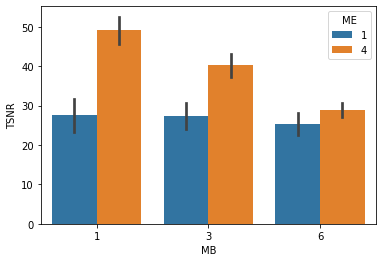

In [8]:

df=pd.DataFrame(data=data,columns=['sub','MB','ME','Striatum','MPFC'])
df.to_csv("TSNRinfo.tsv",sep="\t",index=False)
df=df.melt(id_vars=['sub','MB','ME'],var_name='Region',value_name='TSNR')
display(df.head())
plt_df=df[df['Region']=='Striatum']

sns.barplot(x='MB',y='TSNR',hue='ME',data=plt_df)

In [90]:
img_list

[]


def collect_tsnr(img):
    start = time.time()

    me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
    mb=int(re.search('_acq-mb(.*?)me',img).group(1))
    sub=re.search('func/sub-(.*?)_task',img).group(1)
    print(sub,mb,me)
    #mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)
    
    nifti_masker = NiftiMasker(mask_strategy='background')
    x=nifti_masker.fit_transform(img)
    img=nifti_masker.inverse_transform(x)
    end = time.time()
    print("first maskfit:",end - start)
    print(img.shape)
    
    
    # calculate mean image for the background
    from nilearn.image import math_img
    tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
    img_list=[tsnr_img,me,mb,sub]
    y=str_mask.fit_transform(tsnr_img)
    print("STR maskfit:",end - start)
    z=cort_mask.fit_transform(tsnr_img)
    print("CORT maskfit:",end - start)
    data_row=[sub,mb,me,np.mean(np.abs(x.flatten())),
                 np.mean(np.abs(y.flatten())),
                 np.mean(np.abs(z.flatten()))]
    return([img_list,data_row])

    end = time.time()
    print(end - start)

def driver_func(myfunc,input_list):
    THREADS=10
    with multiprocessing.Pool(THREADS) as pool:
        results=pool.map(myfunc,input_list)
    return(results)
data=driver_func(collect_tsnr,f_list)

for img in img_list:
    plotting.plot_stat_map(img[0],
                      title="tsnr for Sub: %s ME: %s MB: %s "%(img[3],img[1],img[2]),
                      vmax=200,draw_cross=False)
    plt.show()


## Plot tsnr Maps

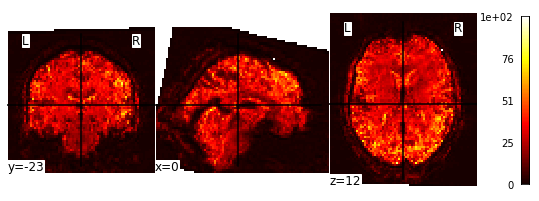

In [6]:
img=f_list[0]

#nifti_masker = NiftiMasker(mask_strategy='epi')
#x=nifti_masker.fit_transform(img)
#img=nifti_masker.inverse_transform(x)
tsnr_img = image.math_img('img.mean(axis=3) / img.std(axis=3)', img=img)
plotting.plot_stat_map(tsnr_img)

[[<nibabel.nifti1.Nifti1Image at 0x7fdd8becb9a0>, 4, 3, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fdd8becbb50>, 4, 1, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fdd8becb580>, 1, 1, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fdd8bdb65e0>, 1, 3, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fdd8bdb67f0>, 4, 6, '10017'],
 [<nibabel.nifti1.Nifti1Image at 0x7fdd8bdb6d90>, 1, 6, '10017']]

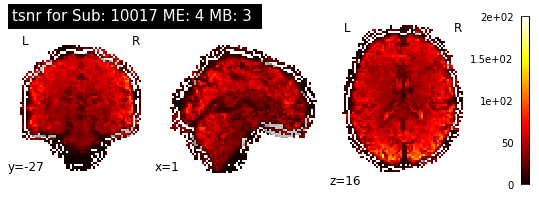

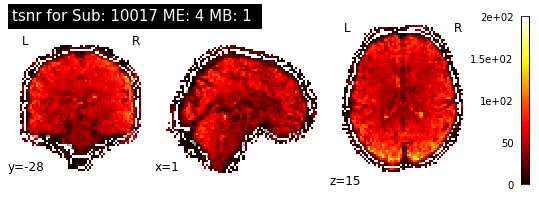

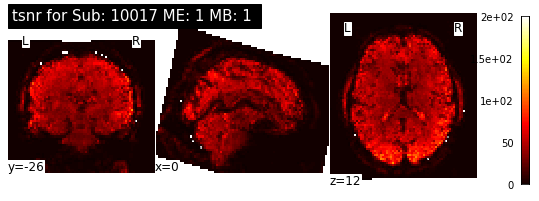

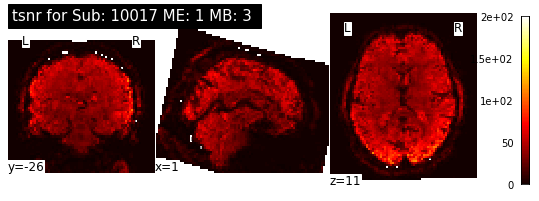

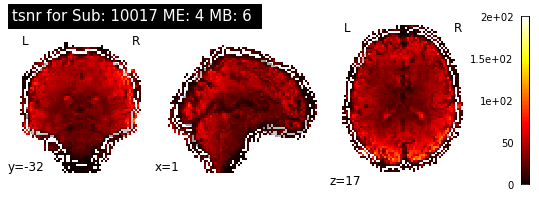

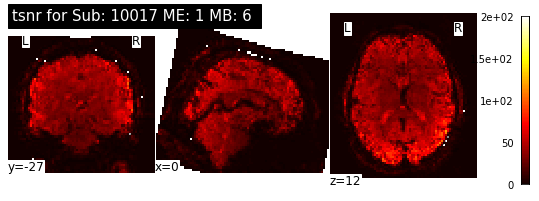

In [7]:
sub='10017'
sub_list=[img for img in img_list if img[3]==sub]
display(sub_list)
for img in sub_list:
    plotting.plot_stat_map(img[0],title="tsnr for Sub: %s ME: %s MB: %s "%(img[3],img[1],img[2]),vmax=200,draw_cross=False)
    plt.show()

# L1 Z-stats
- Heads up these Graphs are interactive

In [11]:
f_list = [os.path.join(root,f) for root,dirs,files in os.walk(
    '../derivatives/fsl/') for f in files if ('zstat' in f) & f.endswith('.nii.gz') ]#  ('stats' in root) &if ('/stats/zstat' in f) & (f.endswith('nii.gz'))]
f_list=[f for f in f_list if ('stats/zstat' in f) & ('L1_task' in f) &('denoise-' in f)&('type-act' in f)]
display(f_list)

['../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/stats/zstat2.nii.gz',
 '../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/stats/zstat14.nii.gz',
 '../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/stats/zstat9.nii.gz',
 '../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/stats/zstat16.nii.gz',
 '../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/stats/zstat11.nii.gz',
 '../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/stats/zstat8.nii.gz',
 '../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/stats/zstat10.nii.gz',
 '../derivatives/fsl/sub-10154/L1_task-sharedreward_model-1_type-act_acq-mb6me4_sm-4_denoise-tedana.feat/st

In [5]:

def collect_zstats(img):
    zstat=int(re.search('thresh_zstat(.*).nii.gz',img).group(1))
    if zstat>10:
        me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
        mb=int(re.search('_acq-mb(.*?)me',img).group(1))
        sub=re.search('fsl/sub-(.*?)/L1',img).group(1)
        mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)
        if mb>1:
            denoise=re.search('_denoise-9(.*).feat',img).group(1)
        else:
            denoise='none'

        nifti_masker = NiftiMasker(mask_strategy='background')
        x=nifti_masker.fit_transform(img)
        img=nifti_masker.inverse_transform(x)

        # calculate mean image for the background
    
        x=nifti_masker.fit_transform(img)
        y=str_mask.fit_transform(img)
        z=cort_mask.fit_transform(img)
        
        img_row=[str_mask.inverse_transform(y),img,zstat,me,mb,sub]

        data_row=[sub,mb,me,denoise,zstat,np.mean(np.abs(x.flatten())),
                     np.mean(np.abs(y.flatten())),
                     np.mean(np.abs(z.flatten()))]
        return(data_row)

def driver_func(myfunc,input_list):
    THREADS=4
    with multiprocessing.Pool(THREADS) as pool:
        data_res=[pool.apply_async(myfunc,p) for p in input_list]
        
res=driver_func(collect_zstats,f_list)
print(res)

None


In [12]:
data=[]
img_list=[]
                                        
good_subs=['10017','10024','10035','10043',
          '10054','10059','10074','10078',
          '10080','10108','10125','10136',
          '10137','10142','10150','10154',
          '10186','10188','10221']
for img in f_list:    
    zstat=int(re.search('zstat(.*).nii.gz',img).group(1))
    if zstat in[5,6,7,8,9,10,13,14,15,16]:
        me=int(re.search('_acq-mb[0-7]me(.*?)_',img).group(1))
        mb=int(re.search('_acq-mb(.*?)me',img).group(1))
        sub=re.search('fsl/sub-(.*?)/L1',img).group(1)
        mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)
        if me>1:
            if '_denoise-' in img:
                denoise=re.search('_denoise-(.*).feat',img).group(1)
            else:
                continue
        else:
            denoise='none'
        if sub in good_subs:

            #mask = re.sub("desc-(.*?).nii.gz","desc-brain_mask.nii.gz",img)

            #nifti_masker = NiftiMasker(mask_strategy='background')
            x=cort_mask.fit_transform(img)

            # calculate mean image for the background

            #x=nifti_masker.fit_transform(img)
            #y=str_mask.fit_transform(img)
            z=str_mask.fit_transform(img)

            #img_list.append([str_mask.inverse_transform(y),img,zstat,me,mb,sub])

            data.append([sub,mb,me,zstat,denoise,np.mean(z.flatten()),np.mean(x.flatten())])

,contrast,sub,MB,ME,denoise,Region,zstat,acq,acq-scrub,condition
0,14,10154,6,4,tedana,Striatum,-0.159701,64,4tedana,RP>N
1,9,10154,6,4,tedana,Striatum,-0.201844,64,4tedana,9
2,16,10154,6,4,tedana,Striatum,0.326165,64,4tedana,N>P
3,8,10154,6,4,tedana,Striatum,-0.760703,64,4tedana,Stranger Punishment
4,10,10154,6,4,tedana,Striatum,-0.562307,64,4tedana,Stranger Reward


,contrast,sub,MB,ME,denoise,Region,zstat,acq,acq-scrub,condition
6,13,10154,6,4,tedana,Striatum,0.463470,64,4tedana,Rew>Pun
16,13,10154,3,4,tedana,Striatum,1.669700,34,4tedana,Rew>Pun
26,13,10154,1,4,tedana,Striatum,-0.037133,14,4tedana,Rew>Pun
36,13,10154,1,4,none,Striatum,-0.240032,14,4none,Rew>Pun
46,13,10154,6,4,none,Striatum,0.504425,64,4none,Rew>Pun


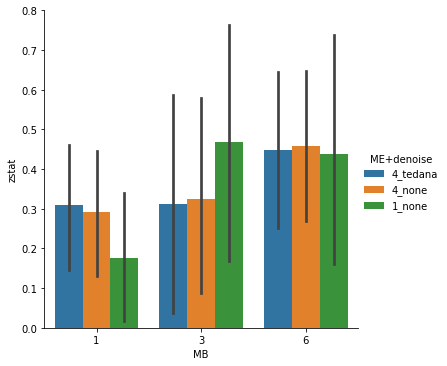

In [23]:
df=pd.DataFrame(data=data,columns=['sub','MB','ME','contrast','denoise','Striatum','PFC'])
df=df.melt(id_vars=['contrast','sub','MB','ME','denoise'],var_name='Region',value_name='zstat')
df['acq']=df["MB"].astype(str) + df["ME"].astype(str)
df['acq-scrub']=df['ME'].astype(str)+df['denoise']
df['condition'] = df['contrast'].replace({5:'Computer Punishment',
                                          7:'Computer Reward',
                                          8:'Stranger Punishment',
                                          10:'Stranger Reward',
                                         13: "Rew>Pun",
                                         14:"RP>N",
                                         15:"R>N",
                                         16:"N>P"})
good_subs=['10017','10024','10035','10043',
          '10054','10059','10074','10078',
          '10080','10108','10125','10136',
          '10137','10142','10150','10154',
          '10186','10188','10221']
display(df.head())
df=df[df['condition'].isin(['Rew>Pun'])]
df=df[df['sub'].isin(good_subs)]
df=df[df['Region']=='Striatum']
display(df.head())
#df[['Player','Reward']] = df.condition.str.split(expand=True)
#plt_df=df[df['Region']=='Striatum']
#plt_df=plt_df[plt_df['Player']=='Stranger']

#plt_df=plt_df.groupby(by=['sub','acq']).mean().reset_index()

#display(plt_df.head())
df['ME+denoise']=df['ME'].astype(str)+'_'+df['denoise']
g=sns.catplot(x='MB',y='zstat',hue='ME+denoise',kind='bar',data=df,ci=95)
g.savefig('Rew-zstat.pdf')
#plt_df=plt_df[plt_df['Reward']=='Reward']
#g=sns.catplot(x='acq',y='zstat',hue='Player',kind='bar',data=plt_df,ci=85,
#              dodge=True,order=['11','14','31','34','61','64'])
#g.savefig('str-zstat.pdf')
#plt_df.head(13)

In [86]:
df

,contrast,sub,MB,ME,Region,zstat,acq,condition


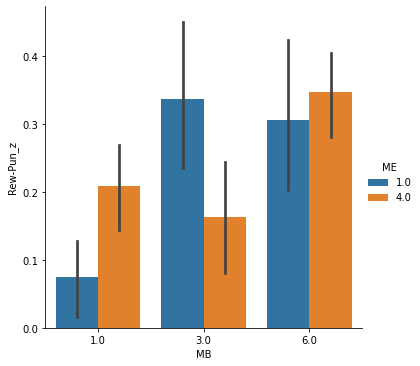

,index,sub,acq,Reward,contrast,MB,ME,zstat,Rew-Pun_z
0,1,10017,11,Reward,8.5,1.0,1.0,-0.238944,-0.269942
1,3,10017,14,Reward,8.5,1.0,4.0,-0.755099,-0.324104
2,5,10017,31,Reward,8.5,3.0,1.0,0.588060,0.341249
3,7,10017,34,Reward,8.5,3.0,4.0,0.034111,0.253196
4,9,10017,61,Reward,8.5,6.0,1.0,-0.059860,0.312277


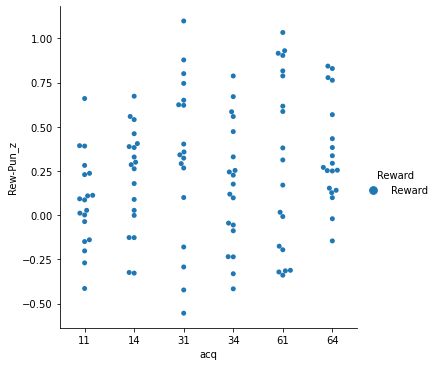

In [73]:
rew=plt_df[plt_df['Reward']=='Reward'].reset_index()
pun=plt_df[plt_df['Reward']=='Punishment'].reset_index()
rew['Rew-Pun_z']=rew['zstat']-pun['zstat']

g=sns.catplot(x='MB',y='Rew-Pun_z',kind='bar', hue='ME',data=rew,ci=68,)

plt.show()
sns.catplot(x='acq',y='Rew-Pun_z',hue='Reward',kind='swarm',data=rew,dodge=True,
            order=['11','14','31','34','61','64'])

#equiv = {11:1, 14:1, 31:3, 34:3,61:6,64:6}
#rew["Band Factor"] = rew["acq"].map(equiv)
#equiv = {11:1, 14:4, 31:1, 34:4,61:1,64:4}
#rew["Echo Factor"] = rew["acq"].map(equiv)
display(rew.head())

plt.show()

In [65]:
display(rew.head(10))
display(pun.head(10))

,index,sub,acq,Reward,contrast,MB,ME,zstat,Rew-Pun_z
0,1,10017,11,Reward,8.0,1.0,1.0,-0.161104,-0.192102
1,3,10017,14,Reward,8.0,1.0,4.0,-0.710661,-0.279666
2,5,10017,31,Reward,8.0,3.0,1.0,0.795051,0.548240
3,7,10017,34,Reward,8.0,3.0,4.0,-0.492667,-0.273581
4,9,10017,61,Reward,8.0,6.0,1.0,-0.126045,0.246093
5,11,10017,64,Reward,8.0,6.0,4.0,0.338582,-0.257445
6,13,10024,11,Reward,8.0,1.0,1.0,0.712473,0.053622
7,15,10024,14,Reward,8.0,1.0,4.0,-0.454977,0.127304
8,17,10024,31,Reward,8.0,3.0,1.0,0.257346,0.246779
9,19,10024,34,Reward,8.0,3.0,4.0,0.178052,0.904459


,index,sub,acq,Reward,contrast,MB,ME,zstat
0,0,10017,11,Punishment,5.166667,1.0,1.0,0.030998
1,2,10017,14,Punishment,6.500000,1.0,4.0,-0.430995
2,4,10017,31,Punishment,6.500000,3.0,1.0,0.246811
3,6,10017,34,Punishment,6.500000,3.0,4.0,-0.219085
4,8,10017,61,Punishment,6.500000,6.0,1.0,-0.372138
5,10,10017,64,Punishment,6.500000,6.0,4.0,0.596026
6,12,10024,11,Punishment,6.500000,1.0,1.0,0.658851
7,14,10024,14,Punishment,6.500000,1.0,4.0,-0.582280
8,16,10024,31,Punishment,6.500000,3.0,1.0,0.010567
9,18,10024,34,Punishment,6.500000,3.0,4.0,-0.726407
